# MICrONS Project
A simple demo showing how to use the CAVE client to query, load, and display information from the MICrONS dataset.

## Initialization
Follow the instructions at [this link](https://tutorial.microns-explorer.org/quickstart_notebooks/01-caveclient-setup.html) to accept the terms of service. Then, you'll need to authenticate with the service through the python package on the first use. This will save the auth token, so you don't have to log in every time.

In [1]:
! pip install caveclient cloud-volume jinja2 seaborn meshparty vtk

In [1]:
dataset_name = 'minnie65_public'
# materialization = 1621  # 11/25/2025
materialization = 1300      # Required for mesh downloading

In [2]:
from caveclient import CAVEclient

client = CAVEclient(dataset_name)
client.info.get_datastack_info()['description']

'This is the publicly released version of the minnie65 volume and segmentation. '

In [3]:
available_versions = client.materialize.get_versions()

print('Available materializations: ')
for version in available_versions:
    print(f"\tVersion {version}: {client.materialize.get_timestamp(version)}")

if materialization not in available_versions:
    print(f'Unknown materialization version: {materialization}')

if materialization != max(available_versions):
    print(f'WARNING: Not using the latest materialization version, { materialization } < { max(available_versions) }')

print(f'Using materialization v{ materialization }')
client.version = materialization

Available materializations: 
	Version 1300: 2025-01-13 10:10:01.286229+00:00
	Version 1078: 2024-06-05 10:10:01.203215+00:00
	Version 117: 2021-06-11 08:10:00.215114+00:00
	Version 661: 2023-04-06 20:17:09.199182+00:00
	Version 343: 2022-02-24 08:10:00.184668+00:00
	Version 1181: 2024-09-16 10:10:01.121167+00:00
	Version 795: 2023-08-23 08:10:01.404268+00:00
	Version 943: 2024-01-22 08:10:01.497934+00:00
	Version 1412: 2025-04-29 10:10:01.200893+00:00
	Version 1507: 2025-07-31 08:10:01.117494+00:00
	Version 1621: 2025-11-25 08:10:01.094430+00:00
Using materialization v1300


# Materialization Contents

Query the client for all available types of data

For a more curated list, visit https://tutorial.microns-explorer.org/annotation-tables.html

In [4]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

def add_line_breaks(text):
    if isinstance(text, str):
        return text.replace('\n', '<br>')
    return text


tables = pd.DataFrame.from_dict(client.materialize.get_tables_metadata())
tables[['table_name', 'description']].style \
    .set_properties(**{'text-align': 'left'}) \
    .format({'description': add_line_breaks})

,table_name,description
0,baylor_gnn_cell_type_fine_model_v2,"Exciatory/Inhibitory Subclass cell types derived from a supervised GNN classifier trained on the hand labeled cell types('23P, 4P, 5P-IT, 5P-NP, 5P-PT, 6P-CT, 6P-IT, BC, BPC, MC, NGC'). Process for generating labels 1) Cells Automatically Proofread 2) Graph Objects generated for each neuron with the following node attributes (no z coordinate information included): skeleton information ('skeletal_length','skeleton_vector_upstream_theta','skeleton_vector_upstream_phi' ,'skeleton_vector_downstream_theta','skeleton_vector_downstream_phi'), width information ('width_upstream','width_no_spine','width_downstream'), synapse information('n_synapses_post','n_synapses_pre','n_synapses_head_postsyn', 'n_synapses_neck_postsyn','n_synapses_shaft_postsyn','n_synapses_no_head_postsyn','synapse_volume_shaft_postsyn_sum', 'synapse_volume_head_postsyn_sum','synapse_volume_no_head_postsyn_sum','synapse_volume_neck_postsyn_sum','synapse_volume_postsyn_sum',), spine information ('n_spines','spine_volume_sum',), global neuron information (""soma_start_angle_max"",""max_soma_volume"",""n_syn_soma"") 3) GCN trained on labeled data with 60:20:20 training/validation/testing split 4) GCN model generates class probabiliites and highest probability label given [Note: This table 'baylor_gnn_cell_type_fine_model_v2' will update the 'target_id' foreign_key when updates are made to the 'nucleus_detection_v0' table]"
1,nucleus_alternative_points,"A table with alternative segid lookup points for nuclei created using an automated method which looked for nuclei centroids outside nuclie, or centroids which were not in the segmentation. The point at least 320 nm within the nucleus and the segmentation, and closet to the original centroid was choosen in a 3um window. Created by Forrest Collman forrestc@alleninstitute.org [Note: This table 'nucleus_alternative_points' will update the 'target_id' foreign_key when updates are made to the 'nucleus_detection_v0' table]"
2,allen_column_mtypes_v2,This table contains the anatomical cell type clusters (m-types) for the Minnie columnar sample described in Schneider-Mizell et al. Biorxiv 2024 (DOI: 10.1101/2023.01.23.525290 v3)
3,bodor_pt_cells,PT cells used by Agnes Bodor and Nuno da Costa for L5PT-specific connectivity project.
4,aibs_metamodel_mtypes_v661_v2,"This table contains Mtype predictions (Schneider-Mizell 2023) for cells throughout the entire dataset at materialization version 661. The predictions come from a soma and nucleus feature trained metamodel (Elabbady 2022). This is a reference table where id refers to the unique nucleus id in the ""nucleus_detection_v0"" table. Classification_system refers to the coarse class predictions (excitatory or inhibitory) and cell_type denotes neuronal mtype predictions. Errors, nonneurons, and soma-soma mergers have been filtered out. For questions please contact Leila Elabbady or Forrest Collman. [Note: This table 'aibs_metamodel_mtypes_v661_v2' will update the 'target_id' foreign_key when updates are made to the 'nucleus_detection_v0' table]"
5,allen_v1_column_types_slanted_ref,"Adaptation of the allen_v1_column_types_v2 table, but with a lower region that follows the natural curvature of the neurons. The direction was estimated from several PT cell axons from within the column. Only neurons are included in this table, not non-neuronal cells. Slanted region and new cell typing was initially done by Casey Schneider-Mizell, with help from Nuno da Costa and Agnes Bodor. [Note: This table 'allen_v1_column_types_slanted_ref' will update the 'target_id' foreign_key when updates are made to the 'nucleus_detection_v0' table]"
6,aibs_column_nonneuronal_ref,"Table cell typing the non-neuronal cells in the same region as allen_v1_column_types_slanted table. Options are microglia, pericyte, oligo (oligodendrocyte), OPC (oligodendrocyte precursor cell), astrocyte, or unsure. Cell typing by JoAnn Buchanan, maintained by Casey Sch

# Query Cell Types

In [6]:
cell_type_df = client.materialize.query_table('nucleus_detection_v0', split_positions=True, desired_resolution=[1, 1, 1], limit=10)
cell_type_df.head()

201 - "Limited query to 10 rows


,id,created,superceded_id,valid,volume,pt_position_x,pt_position_y,pt_position_z,bb_start_position_x,bb_start_position_y,bb_start_position_z,bb_end_position_x,bb_end_position_y,bb_end_position_z,pt_supervoxel_id,pt_root_id
0,996,2020-09-28 22:40:49.459189+00:00,<NA>,True,35.147778,241856,374464,838720,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0
1,1833,2020-09-28 22:42:05.748213+00:00,<NA>,True,35.934044,227200,389120,797160,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0
2,1841,2020-09-28 22:44:35.992946+00:00,<NA>,True,265.585938,230144,422336,795320,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0
3,1896,2020-09-28 22:43:54.059800+00:00,<NA>,True,174.558411,239488,386432,794120,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0
4,1998,2020-09-28 22:43:41.083981+00:00,<NA>,True,137.669342,239744,423488,803120,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,72978435697419638,864691136050815731


In [7]:
help(client.materialize.tables.aibs_metamodel_celltypes_v661)

Help on class aibs_metamodel_celltypes_v661 in module caveclient.tools.table_manager:

class aibs_metamodel_celltypes_v661(TableQueryKwargs)
 |  aibs_metamodel_celltypes_v661(pt_root_id=None, id=None, volume=None, id_ref=None, cell_type=None, classification_system=None, target_id=None, pt_position_bbox=None, bb_end_position_bbox=None, bb_start_position_bbox=None) -> None
 |
 |  This table contains anatomical cell-type predictions for cells throughout the entire dataset at materialization version 661. The predictions come from a soma and nucleus feature trained metamodel (Elabbady 2022). This is a reference table where id refers to the unique nucleus id in the "nucleus_detection_v0" table. Classification_system refers to the coarse class predictions and cell_type denotes nonneuronal class and neuronal subclass predictions. Errors and soma-soma mergers have been filtered out. For questions please contact Leila Elabbady or Forrest Collman. [Note: This table 'aibs_metamodel_celltypes_v661'

In [8]:
cell_type_df = client.materialize.tables.aibs_metamodel_celltypes_v661().query(desired_resolution=[1,1,1], limit=10)
cell_type_df.head()

201 - "Limited query to 10 rows


,id,created,valid,volume,pt_supervoxel_id,pt_root_id,id_ref,created_ref,valid_ref,target_id,classification_system,cell_type,pt_position,bb_start_position,bb_end_position
0,3813,2020-09-28 22:40:51.242256+00:00,True,255.728195,73613884698831796,864691135724233643,44795,2023-12-19 22:49:22.401240+00:00,True,3813,excitatory_neuron,23P,"[257600, 487936, 802760]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
1,3819,2020-09-28 22:42:03.717937+00:00,True,310.794159,73754828345558830,864691136436395166,44796,2023-12-19 22:49:22.414725+00:00,True,3819,excitatory_neuron,23P,"[260992, 493568, 801560]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
2,4072,2020-09-28 22:43:23.675858+00:00,True,324.996307,73613197571380105,864691135462260637,50039,2023-12-19 22:50:41.912894+00:00,True,4072,inhibitory_neuron,NGC,"[256256, 466432, 831040]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
3,4074,2020-09-28 22:42:41.341179+00:00,True,313.678223,73543309863605007,864691136723556861,50080,2023-12-19 22:50:42.474168+00:00,True,4074,excitatory_neuron,23P,"[255744, 480640, 833200]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
4,4078,2020-09-28 22:40:44.089696+00:00,True,322.528229,73755240729611855,864691135776658528,50174,2023-12-19 22:50:43.738944+00:00,True,4078,excitatory_neuron,23P,"[262144, 505856, 824880]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


In [9]:
cell_type_df = client.materialize.tables.aibs_metamodel_celltypes_v661().query(desired_resolution=[1,1,1])
cell_type_df.groupby(by=['cell_type', 'classification_system', 'valid']).count()

,,,id,created,volume,pt_supervoxel_id,pt_root_id,id_ref,created_ref,valid_ref,target_id,pt_position,bb_start_position,bb_end_position
cell_type,classification_system,valid,,,,,,,,,,,,
23P,excitatory_neuron,True,19735,19735,19735,19735,19735,19735,19735,19735,19735,19735,19735,19735
4P,excitatory_neuron,True,14777,14777,14777,14777,14777,14777,14777,14777,14777,14777,14777,14777
5P-ET,excitatory_neuron,True,2215,2215,2215,2215,2215,2215,2215,2215,2215,2215,2215,2215
5P-IT,excitatory_neuron,True,7949,7949,7949,7949,7949,7949,7949,7949,7949,7949,7949,7949
5P-NP,excitatory_neuron,True,970,970,970,970,970,970,970,970,970,970,970,970
6P-CT,excitatory_neuron,True,6815,6815,6815,6815,6815,6815,6815,6815,6815,6815,6815,6815
6P-IT,excitatory_neuron,True,11734,11734,11734,11734,11734,11734,11734,11734,11734,11734,11734,11734
BC,inhibitory_neuron,True,3365,3365,3365,3365,3365,3365,3365,3365,3365,3365,3365,3365
BPC,inhibitory_neuron,True,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488


# Proofreading

In [10]:
proof_all_df = client.materialize.query_table("proofreading_status_and_strategy", 
                                              desired_resolution=[1, 1, 1])
proof_all_df.head()

,id,created,superceded_id,valid,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id,pt_root_id,pt_position
0,1,2024-06-03 19:45:52.501252+00:00,<NA>,True,864691135441799752,True,True,dendrite_extended,axon_interareal,91346396048860133,864691135441799752,"[772608, 475904, 840840]"
1,3,2024-06-03 19:45:52.503198+00:00,<NA>,True,864691135855890478,True,True,dendrite_extended,axon_interareal,84591134382832426,864691135855890478,"[576288, 479860, 961960]"
2,4,2024-06-03 19:45:52.504040+00:00,<NA>,True,864691136521831825,True,True,dendrite_extended,axon_interareal,109368765749515987,864691136521831825,"[1298352, 711824, 768840]"
3,5,2024-06-03 19:45:52.504877+00:00,<NA>,True,864691135952122147,True,True,dendrite_extended,axon_interareal,112175063088115757,864691135952122147,"[1379072, 461400, 791440]"
4,7,2024-06-03 19:45:52.506448+00:00,<NA>,True,864691135163673901,True,True,dendrite_extended,axon_fully_extended,89737260647882239,864691135163673901,"[726208, 754048, 816880]"


In [11]:
proof_all_df.pivot_table(index='strategy_dendrite', columns=['strategy_axon'], values='id', aggfunc='count')

strategy_axon,axon_fully_extended,axon_interareal,axon_partially_extended,none
strategy_dendrite,,,,
dendrite_clean,10,63,507,<NA>
dendrite_extended,117,67,940,149
none,<NA>,<NA>,12,<NA>


In [12]:
proof_dendrite_df = client.materialize.tables \
    .proofreading_status_and_strategy(
        strategy_dendrite=['dendrite_clean', 'dedrite_extended']
    ) \
    .query(
        select_columns=['id', 'pt_root_id', 'strategy_dendrite', 'strategy_axon']
    )
proof_dendrite_df.head()

,id,pt_supervoxel_id,pt_root_id,strategy_dendrite,strategy_axon
0,1522,90782415236377623,864691136445280131,dendrite_clean,axon_partially_extended
1,1527,88040714474248621,864691135701896315,dendrite_clean,axon_partially_extended
2,1528,89375590041880542,864691135136188185,dendrite_clean,axon_partially_extended
3,1532,88601327898256679,864691135519025802,dendrite_clean,axon_partially_extended
4,1534,89166545661876847,864691136663700958,dendrite_clean,axon_partially_extended


In [13]:
cell_type_df = cell_type_df \
    .drop_duplicates('pt_root_id', keep=False) \
    .rename(columns={'id' : 'nucleus_id'})
cell_type_df.head()

,nucleus_id,created,valid,volume,pt_supervoxel_id,pt_root_id,id_ref,created_ref,valid_ref,target_id,classification_system,cell_type,pt_position,bb_start_position,bb_end_position
0,336365,2020-09-28 22:42:48.966292+00:00,True,272.48819,93606511657924288,864691136274724621,36916,2023-12-19 22:47:18.659864+00:00,True,336365,excitatory_neuron,5P-IT,"[839040, 723328, 1083040]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
1,110648,2020-09-28 22:45:09.650639+00:00,True,328.533447,79385153184885329,864691135489403194,1070,2023-12-19 22:38:00.472115+00:00,True,110648,excitatory_neuron,23P,"[425792, 518528, 1016400]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
2,112071,2020-09-28 22:43:34.088785+00:00,True,272.929413,79035988248401958,864691136147292311,1099,2023-12-19 22:38:00.898837+00:00,True,112071,excitatory_neuron,23P,"[414784, 597888, 623320]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
3,197927,2020-09-28 22:43:10.652649+00:00,True,91.308853,84529699506051734,864691136050858227,13259,2023-12-19 22:41:14.417986+00:00,True,197927,nonneuron,oligo,"[574400, 744768, 1058840]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
4,198087,2020-09-28 22:41:36.677186+00:00,True,161.74498,83756261929388963,864691135809440972,13271,2023-12-19 22:41:14.685474+00:00,True,198087,nonneuron,astrocyte,"[551808, 763776, 1094440]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


In [14]:
joined = pd.merge(proof_dendrite_df, cell_type_df, on='pt_root_id', how='inner')
joined.head()

,id,pt_supervoxel_id_x,pt_root_id,strategy_dendrite,strategy_axon,nucleus_id,created,valid,volume,pt_supervoxel_id_y,id_ref,created_ref,valid_ref,target_id,classification_system,cell_type,pt_position,bb_start_position,bb_end_position
0,1522,90782415236377623,864691136445280131,dendrite_clean,axon_partially_extended,292674,2020-09-28 22:45:11.529117+00:00,True,334.372528,90782415236377623,28139,2023-12-19 22:45:06.108126+00:00,True,292674,excitatory_neuron,23P,"[757184, 443904, 826040]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
1,1527,88040714474248621,864691135701896315,dendrite_clean,axon_partially_extended,258353,2020-09-28 22:44:02.531562+00:00,True,209.294952,88040714474248621,22905,2023-12-19 22:43:45.756473+00:00,True,258353,excitatory_neuron,23P,"[677312, 523648, 884400]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
2,1528,89375590041880542,864691135136188185,dendrite_clean,axon_partially_extended,256470,2020-09-28 22:43:08.826020+00:00,True,242.519897,89375590041880542,22239,2023-12-19 22:43:36.773027+00:00,True,256470,excitatory_neuron,23P,"[716864, 460544, 818280]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
3,1532,88601327898256679,864691135519025802,dendrite_clean,axon_partially_extended,256531,2020-09-28 22:45:07.728670+00:00,True,322.802307,88601327898256679,22268,2023-12-19 22:43:37.183229+00:00,True,256531,excitatory_neuron,23P,"[693440, 453952, 860920]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
4,1534,89166545661876847,864691136663700958,dendrite_clean,axon_partially_extended,258391,2020-09-28 22:44:06.340521+00:00,True,216.626785,89166545661876847,22924,2023-12-19 22:43:46.005254+00:00,True,258391,excitatory_neuron,23P,"[709568, 521664, 894080]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


# Synapses
Plot a connectivity map of all proof read neurons

In [15]:
# Took 8m 54s to complete
proof_df = client.materialize.tables.proofreading_status_and_strategy(status_axon=True).query(desired_resolution=[1, 1, 1], split_positions=True)
syn_proof_only_df = client.materialize.synapse_query(pre_ids=proof_df.pt_root_id, post_ids=proof_df.pt_root_id, remove_autapses=True)
print(len(syn_proof_only_df))

158931


c:\Users\kopal\anaconda3\envs\microns\Lib\site-packages\caveclient\materializationengine.py:1745: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  return df.query("pre_pt_root_id!=post_pt_root_id")


In [16]:
import numpy as np

# Took 2m 25s
syn_mat = syn_proof_only_df.pivot_table(index='pre_pt_root_id', columns='post_pt_root_id', values='size', aggfunc=lambda x: float(np.sum(x) > 0)).fillna(0)
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index))

Text(0.5, 1.0, 'Connectivity between proofread cells')

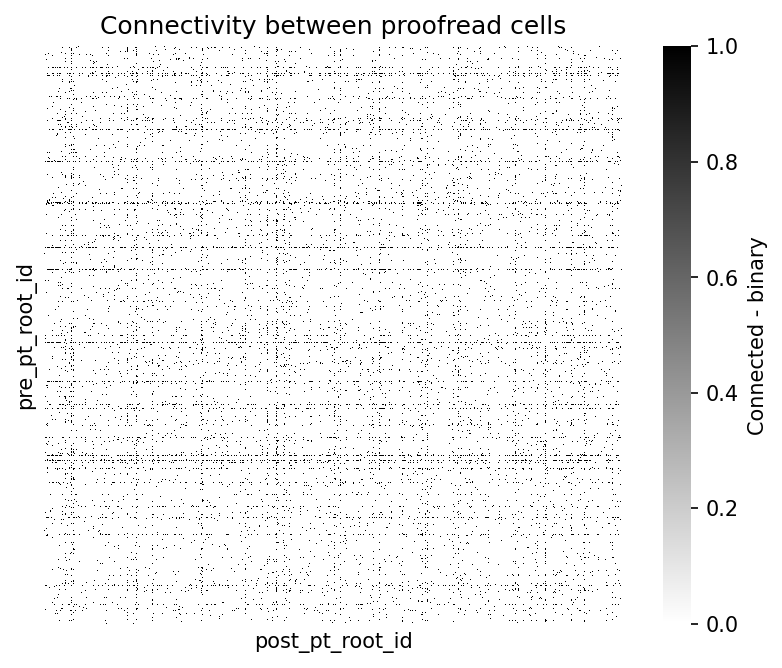

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7,5), dpi=150)
sns.heatmap(syn_mat.astype(float), cmap='gray_r', xticklabels=[], yticklabels=[],
    ax=ax, square=True,
    cbar_kws={'label': 'Connected - binary'})
ax.set_title('Connectivity between proofread cells')

In [5]:
ct_manual_df = client.materialize.tables \
    .allen_v1_column_types_slanted_ref() \
    .query() \
    .rename(columns={'target_id': 'nucleus_id'}) \
    .drop_duplicates('pt_root_id', keep=False)

ct_auto_df = client.materialize.tables \
    .aibs_metamodel_celltypes_v661() \
    .query() \
    .rename(columns={'target_id': 'nucleus_id'}) \
    .drop_duplicates('pt_root_id', keep=False)

indices = ['pt_root_id', 'classification_system', 'cell_type', 'nucleus_id']

ct_all_df = pd.merge(
    ct_auto_df[indices], ct_manual_df[indices], 
    on=['pt_root_id', 'nucleus_id'], 
    how='outer', 
    suffixes=['_auto', '_manual']
    )

ct_all_df['cell_type'] = ct_all_df['cell_type_manual'].fillna(ct_all_df['cell_type_auto'])
ct_all_df['classification_system'] = ct_all_df['classification_system_manual'].fillna(ct_all_df['classification_system_auto'])

ct_all_df = ct_all_df.fillna({
        'cell_type_auto': 'unknown',
        'classification_system_auto': 'unknown',
        'cell_type_manual': 'unknown',
        'classification_system_manual': 'unknown'
    })

In [19]:
ct_all_df.pivot_table(index='cell_type_manual', columns='cell_type_auto', values='pt_root_id', aggfunc='count').fillna(0)

cell_type_auto,23P,4P,5P-ET,5P-IT,5P-NP,6P-CT,6P-IT,BC,BPC,MC,NGC,OPC,astrocyte,microglia,oligo,pericyte,unknown
cell_type_manual,,,,,,,,,,,,,,,,,
23P,337,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4P,2,252,0,12,0,0,0,0,0,0,0,0,0,0,0,0,0
5P-IT,0,15,4,116,0,0,0,0,1,1,0,0,0,0,0,0,0
5P-NP,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0
5P-PT,0,0,33,3,0,0,0,0,0,2,0,0,0,0,0,0,0
6P-CT,0,0,1,0,0,110,31,0,0,0,0,0,0,0,0,0,1
6P-IT,0,0,0,4,0,27,158,0,0,0,0,0,0,0,0,0,3
6P-U,0,0,0,1,0,11,16,0,0,0,0,0,0,0,0,0,0
BC,0,0,0,0,0,0,0,58,0,0,0,0,0,0,0,0,1


In [20]:
ct_all_df.pivot_table(index='classification_system_manual', columns='classification_system_auto', values='pt_root_id', aggfunc='count').fillna(0)

classification_system_auto,excitatory_neuron,inhibitory_neuron,nonneuron,unknown
classification_system_manual,,,,
aibs_coarse_excitatory,1162,4,0,22
aibs_coarse_inhibitory,16,144,0,4
aibs_coarse_unclear,1,0,0,4
unknown,62578,7699,18699,0


In [21]:
exc_root_ids = ct_all_df.query("classification_system.str.contains('excitatory')").pt_root_id.to_numpy()
exc_syn_df = syn_proof_only_df.loc[
    (syn_proof_only_df.pre_pt_root_id.isin(exc_root_ids)) & 
    (syn_proof_only_df.post_pt_root_id.isin(exc_root_ids))
]
exc_syn_mat = exc_syn_df \
    .pivot_table(
        index='pre_pt_root_id', columns='post_pt_root_id', values='size', 
        aggfunc=lambda x: float(np.sum(x) > 0)
    ) \
    .fillna(0)
exc_syn_mat = exc_syn_mat.reindex(columns=np.array(exc_syn_mat.index))


C:\Users\kopal\AppData\Local\Temp\ipykernel_65272\3830375902.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  exc_root_ids = ct_all_df.query("classification_system.str.contains('excitatory')").pt_root_id.to_numpy()


In [22]:
def sort_matrix_by_types(mat: pd.DataFrame,
                         labels: pd.DataFrame,
                         label_type_col: str = 'cell_type',
                         label_id_col: str = 'pt_root_id',
                         post_labels = None,
                         post_label_type_col = None,
                         post_label_id_col = None):
    
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """

    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col

    mat_sorted = mat.copy()

    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]
    

In [23]:
syn_mat_ct, syn_mat_ct_labels, _ = sort_matrix_by_types(exc_syn_mat, ct_all_df)

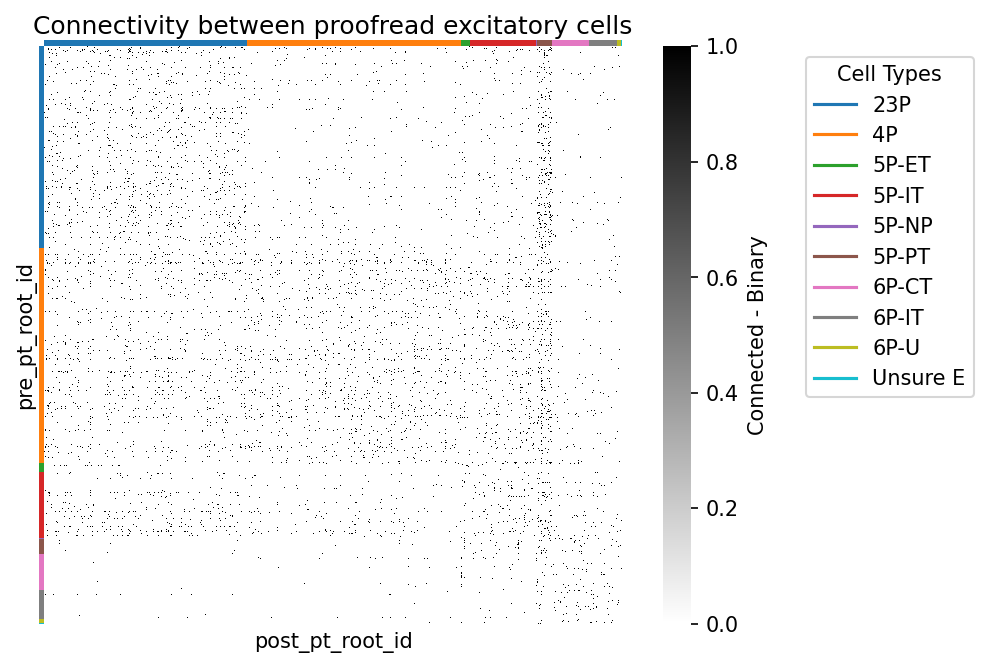

In [24]:
import matplotlib

cts, ct_idx = np.unique(syn_mat_ct_labels, return_inverse=True)
ct_colors = plt.get_cmap('tab10')(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct.astype(float), cmap='gray_r', xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={'label': 'Connected - Binary'})

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))
    
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))
    
legend_elements = [
    matplotlib.lines.Line2D([0], [0], color=plt.get_cmap('tab10')(i), label=ct)
    for i, ct in enumerate(cts)
]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title='Cell Types')

ax.set_title('Connectivity between proofread excitatory cells')
plt.show()

In [25]:
syn_proof_ct_df = syn_proof_only_df.merge(
        ct_all_df[['pt_root_id', 'cell_type']],
        left_on='pre_pt_root_id',
        right_on='pt_root_id',
        how='left'
    ) \
    .rename(columns={ 'cell_type': 'cell_type_pre' }) \
    .drop(columns=['pt_root_id']) \
    .merge(
        ct_all_df[['pt_root_id', 'cell_type']],
        left_on='post_pt_root_id',
        right_on='pt_root_id',
        how='left'
    ) \
    .rename(columns={ 'cell_type': 'cell_type_post' }) \
    .drop(columns=['pt_root_id'])

syn_proof_ct_df.tail()

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position,cell_type_pre,cell_type_post
158926,169135366,2020-11-04 14:11:14.134148+00:00,<NA>,True,5436.0,89596454641249900,864691135763975990,89596454641241738,864691136437883550,"[180384, 187794, 21848]","[180488, 187702, 21835]","[180432, 187782, 21843]",BC,5P-IT
158927,166395590,2020-11-04 09:12:49.205306+00:00,<NA>,True,6496.0,89525398769305088,864691136674556295,89525398769283786,864691136437883550,"[180072, 182912, 22272]","[180040, 182880, 22265]","[180055, 182951, 22269]",BC,5P-IT
158928,167525342,2020-11-04 08:48:35.679627+00:00,<NA>,True,4768.0,89595217690536025,864691136674556295,89595217690524092,864691136437883550,"[180490, 178654, 21756]","[180414, 178598, 21741]","[180469, 178590, 21747]",BC,5P-IT
158929,152649146,2020-11-04 13:02:13.024144+00:00,<NA>,True,1892.0,88673345977259087,864691135572814885,88673345977244151,864691136437883550,"[173636, 126026, 22277]","[173704, 126042, 22263]","[173645, 125935, 22271]",4P,5P-IT
158930,112184560,2020-11-04 13:50:49.701162+00:00,<NA>,True,1240.0,85512250248545880,864691135571546917,85512250248542305,864691136437883550,"[150658, 166810, 23655]","[150716, 166818, 23650]","[150729, 166875, 23651]",MC,5P-IT


In [26]:
syn_ct_counts = syn_proof_ct_df.pivot_table(
        index='cell_type_pre',
        columns='cell_type_post',
        values='id',
        aggfunc='count'
    ) \
    .fillna(0) \
    .astype(int)

syn_ct_counts = syn_ct_counts.reindex(sorted(syn_ct_counts.columns), axis=1)
syn_ct_counts = syn_ct_counts.reindex(sorted(syn_ct_counts.index), axis=0)

syn_ct_counts = syn_ct_counts.rename_axis(['presyn cell type'], axis=0)
syn_ct_counts = syn_ct_counts.rename_axis(['postsyn cell type'], axis=1)

syn_ct_counts

postsyn cell type,23P,4P,5P-ET,5P-IT,5P-NP,5P-PT,6P-CT,6P-IT,6P-U,BC,BPC,MC,NGC,Unsure E,Unsure I
presyn cell type,,,,,,,,,,,,,,,
23P,7690,1968,311,999,2,2426,232,183,28,5431,752,5445,316,2,28
4P,5484,7453,196,2591,2,1481,463,310,59,5592,501,3688,227,1,22
5P-ET,84,29,30,54,1,36,23,9,3,184,9,94,0,0,2
5P-IT,2034,1118,110,874,2,555,276,154,34,1734,202,992,113,2,29
5P-NP,0,0,3,4,0,18,22,17,3,24,2,17,0,0,12
5P-PT,59,35,11,126,8,84,85,38,11,733,22,412,5,0,10
6P-CT,62,161,78,128,9,85,179,113,22,209,16,593,7,2,326
6P-IT,90,83,16,53,7,46,178,112,13,486,20,164,28,1,151
6P-U,1,21,4,14,2,8,57,18,5,87,3,69,1,0,37


Text(0.5, 1.0, 'Aggregate Connectivity between proofread cells')

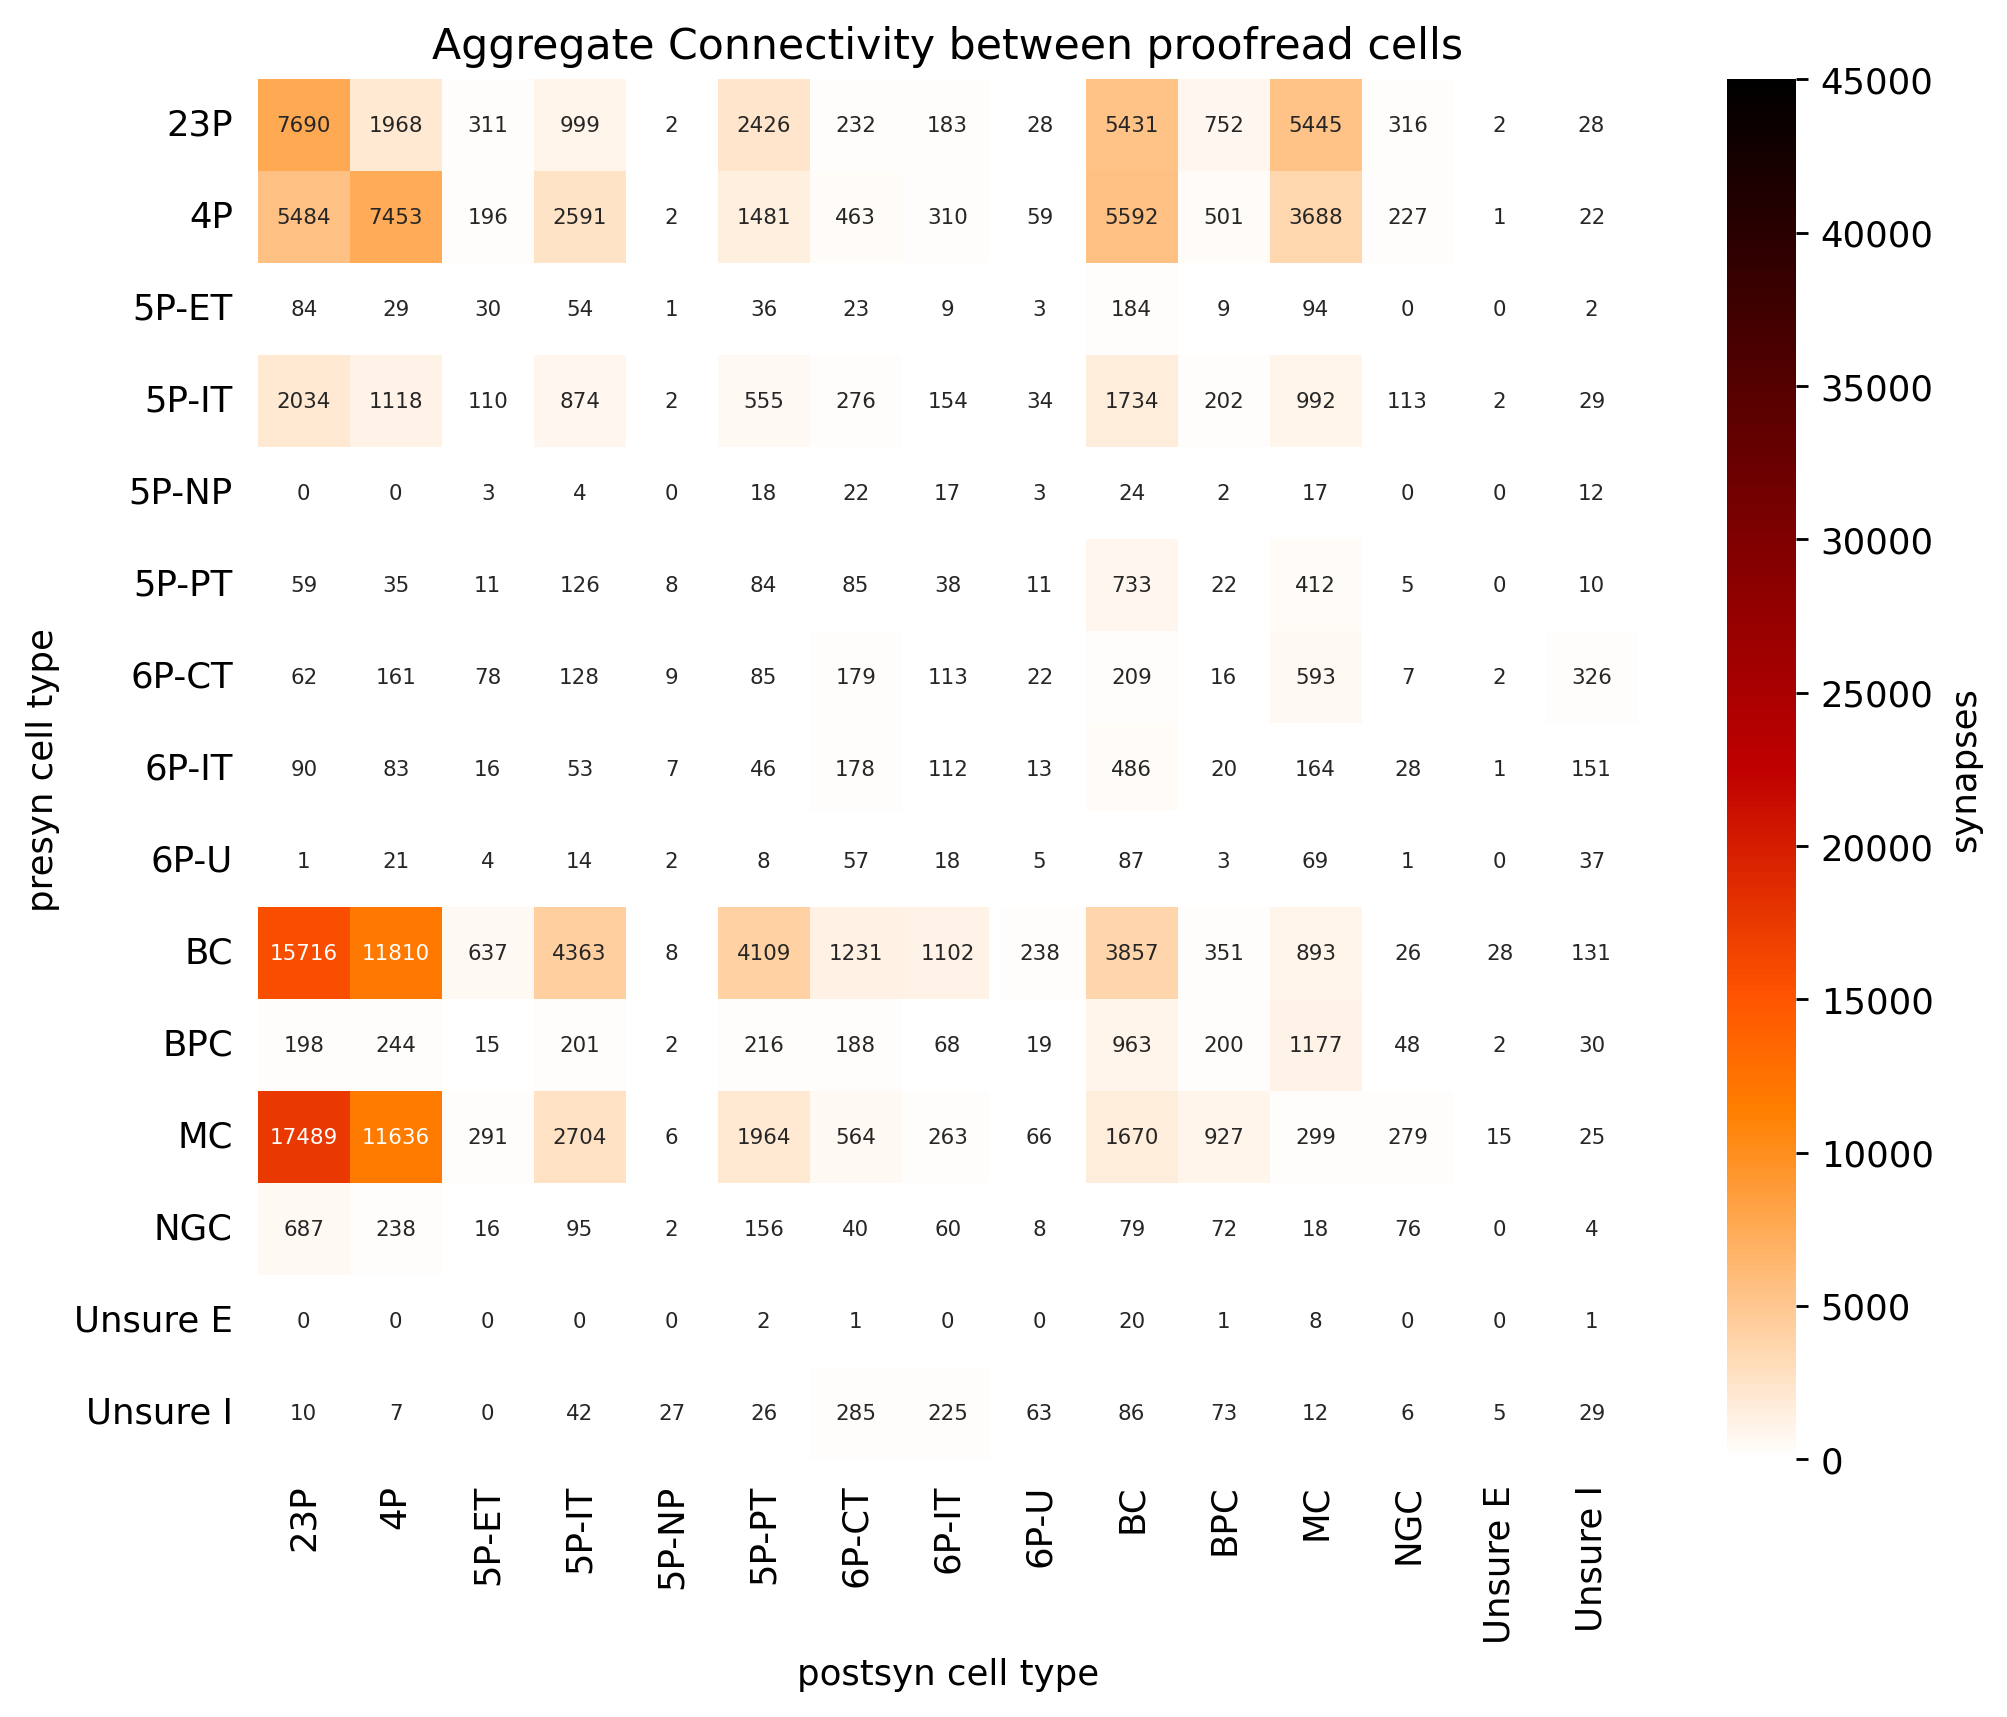

In [27]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=256)

sns.heatmap(syn_ct_counts, cmap='gist_heat_r', annot=True, ax=ax, fmt='d', vmin=0, vmax=45000,
            cbar_kws={'label': 'synapses', 'location': 'right'},
            annot_kws={'fontsize': 6},
            square=True)

ax.tick_params(left=False, bottom=False)
ax.hlines([8], *ax.get_xlim(), color='white',linewidth = 3)
ax.vlines([8], *ax.get_ylim(), color='white',linewidth = 3)

ax.set_title('Aggregate Connectivity between proofread cells')

# Cloud Volume

In [6]:
from cloudvolume import CloudVolume

cv = CloudVolume(client.info.segmentation_source(), progress=True, use_https=True)

In [7]:
ct_manual_df.head()

,id_ref,created_ref,valid_ref,nucleus_id,classification_system,cell_type,id,created,valid,volume,pt_supervoxel_id,pt_root_id,pt_position,bb_start_position,bb_end_position
0,50,2023-03-18 14:13:21.613360+00:00,True,258319,aibs_coarse_excitatory,23P,258319,2020-09-28 22:40:42.476911+00:00,True,261.806152,89309001002848425,864691136021936376,"[178400, 143248, 21238]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
1,1119,2023-03-18 14:13:22.506660+00:00,True,276438,aibs_coarse_excitatory,6P-CT,276438,2020-09-28 22:40:42.700226+00:00,True,277.317719,89465269428261699,864691136487559186,"[179648, 258768, 23597]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
2,35,2023-03-18 14:13:21.602813+00:00,True,260552,aibs_coarse_excitatory,23P,260552,2020-09-28 22:40:42.745779+00:00,True,230.111801,89170256379033022,864691135784109363,"[177408, 157968, 21002]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
3,95,2023-03-18 14:13:21.644304+00:00,True,260263,aibs_coarse_excitatory,23P,260263,2020-09-28 22:40:42.746658+00:00,True,274.324188,88044356338331571,864691135694415551,"[169440, 158128, 20266]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"
4,81,2023-03-18 14:13:21.634505+00:00,True,262898,aibs_coarse_inhibitory,BPC,262898,2020-09-28 22:40:42.749245+00:00,True,230.092316,88468836747612860,864691135759892302,"[172512, 175280, 21964]","[<NA>, <NA>, <NA>]","[<NA>, <NA>, <NA>]"


In [13]:
ct_manual_df.iloc[:5].to_json()

'{"id_ref":{"0":50,"1":1119,"2":35,"3":95,"4":81},"created_ref":{"0":1679148801613,"1":1679148802506,"2":1679148801602,"3":1679148801644,"4":1679148801634},"valid_ref":{"0":true,"1":true,"2":true,"3":true,"4":true},"nucleus_id":{"0":258319,"1":276438,"2":260552,"3":260263,"4":262898},"classification_system":{"0":"aibs_coarse_excitatory","1":"aibs_coarse_excitatory","2":"aibs_coarse_excitatory","3":"aibs_coarse_excitatory","4":"aibs_coarse_inhibitory"},"cell_type":{"0":"23P","1":"6P-CT","2":"23P","3":"23P","4":"BPC"},"id":{"0":258319,"1":276438,"2":260552,"3":260263,"4":262898},"created":{"0":1601332842476,"1":1601332842700,"2":1601332842745,"3":1601332842746,"4":1601332842749},"valid":{"0":true,"1":true,"2":true,"3":true,"4":true},"volume":{"0":261.8061523438,"1":277.3177185059,"2":230.1118011475,"3":274.3241882324,"4":230.0923156738},"pt_supervoxel_id":{"0":89309001002848425,"1":89465269428261699,"2":89170256379033022,"3":88044356338331571,"4":88468836747612860},"pt_root_id":{"0":8646

In [8]:
from meshparty import trimesh_io, trimesh_vtk

mm =  trimesh_io.MeshMeta(
    cv_path=client.info.segmentation_source(),
    disk_cache_path='meshes'
)

cell_id = ct_manual_df[
        (ct_manual_df['classification_system'] == 'aibs_coarse_excitatory') &
        (ct_manual_df['cell_type'] == '23P')
    ] \
    .sort_values(by='volume', ascending=False) \
    ['pt_root_id'][0]

print(f'Cell ID: { cell_id }')

mesh = mm.mesh(seg_id=cell_id)
mesh.add_link_edges(seg_id=cell_id, client=client.chunkedgraph)

Cell ID: 864691136021936376


In [9]:
mesh.is_watertight

False

In [10]:
mesh.faces.shape

(3431281, 3)

In [11]:
mesh.extents

array([290052., 530439., 259182.])

In [10]:
mesh_actor = trimesh_vtk.mesh_actor(
    mesh,
    color=(1,0,0),
    opacity=0.5
)
trimesh_vtk.render_actors([mesh_actor])

<vtkmodules.vtkRenderingOpenGL2.vtkOpenGLRenderer(0x000001C3F99FD540) at 0x000001C4426D7160>